In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [10]:
from src.preprocess import load_data
churn_df = load_data()
dict_df = load_data('data/insurance_policyholder_churn_data_dictionary.csv')

print(churn_df.head())
print(dict_df.head())


   customer_id  as_of_date         region_name  age age_band marital_status  \
0            1  2025-12-31  Manawatu-Whanganui   24    18-24        Married   
1            2  2025-12-31            Auckland   70    65-74        Married   
2            3  2025-12-31       Bay of Plenty   62    55-64        Married   
3            4  2025-12-31       Bay of Plenty   47    45-54         Single   
4            5  2025-12-31       Bay of Plenty   47    45-54        Married   

   customer_tenure_months  multi_policy_flag  num_policies policy_type  ...  \
0                     128                  1             4        Auto  ...   
1                      76                  1             3        Auto  ...   
2                     129                  0             1        Auto  ...   
3                     104                  0             1        Auto  ...   
4                      22                  1             3        Life  ...   

   avg_settlement_time_days  days_since_last_claim

In [11]:
churn_df.info()
dict_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  50000 non-null  int64  
 1   as_of_date                   50000 non-null  object 
 2   region_name                  50000 non-null  object 
 3   age                          50000 non-null  int64  
 4   age_band                     50000 non-null  object 
 5   marital_status               50000 non-null  object 
 6   customer_tenure_months       50000 non-null  int64  
 7   multi_policy_flag            50000 non-null  int64  
 8   num_policies                 50000 non-null  int64  
 9   policy_type                  50000 non-null  object 
 10  renewal_month                50000 non-null  int64  
 11  current_premium              50000 non-null  float64
 12  premium_last_year            50000 non-null  float64
 13  premium_change_p

In [12]:
churn_df.describe()
dict_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  50000 non-null  int64  
 1   as_of_date                   50000 non-null  object 
 2   region_name                  50000 non-null  object 
 3   age                          50000 non-null  int64  
 4   age_band                     50000 non-null  object 
 5   marital_status               50000 non-null  object 
 6   customer_tenure_months       50000 non-null  int64  
 7   multi_policy_flag            50000 non-null  int64  
 8   num_policies                 50000 non-null  int64  
 9   policy_type                  50000 non-null  object 
 10  renewal_month                50000 non-null  int64  
 11  current_premium              50000 non-null  float64
 12  premium_last_year            50000 non-null  float64
 13  premium_change_p

In [13]:
# 날짜가 몇 종류나 있는지 확인
print(churn_df['as_of_date'].nunique())

1


### 가설 2: "보험금 청구(Claim)가 거절되었거나, 보상 금액에 만족하지 못한 고객은 즉시 이탈할 것이다."
    - **분석 포인트:** `Claims Status`가 'Denied'인 그룹의 이탈률 비교.

In [24]:
# 폰트 깨짐 방지
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False) # 마이너스 기호 깨짐 방지

In [25]:
# 1. 분석용 파생 변수 생성
# 거절 경험 유무
churn_df['is_rejected'] = churn_df['num_rejected_claims_12m'] > 0
# 청구 대비 거절 비율 (만족도 간접 지표)
churn_df['rejection_rate'] = churn_df['num_rejected_claims_12m'] / (churn_df['num_claims_12m'] + 1e-9)

# ---------------------------------------------------------
#  가설 검증하기
# ---------------------------------------------------------
print("="*50)
print("1. [가설 검증] 보상 거절 경험 여부에 따른 이탈률")
reject_stats = churn_df.groupby('is_rejected')['churn_flag'].agg(['mean', 'count']).reset_index()
reject_stats.columns = ['거절 경험 여부', '이탈률(평균)', '고객 수']
print(reject_stats)
print("-" * 50)

print("2. [가설 검증] 거절 횟수별 이탈률 추이")
count_stats = churn_df.groupby('num_rejected_claims_12m')['churn_flag'].mean().reset_index()
count_stats.columns = ['거절 횟수', '이탈률']
print(count_stats)
print("="*50)

1. [가설 검증] 보상 거절 경험 여부에 따른 이탈률
   거절 경험 여부   이탈률(평균)   고객 수
0     False  0.298093  49508
1      True  0.660569    492
--------------------------------------------------
2. [가설 검증] 거절 횟수별 이탈률 추이
   거절 횟수       이탈률
0      0  0.298093
1      1  0.659751
2      2  0.700000


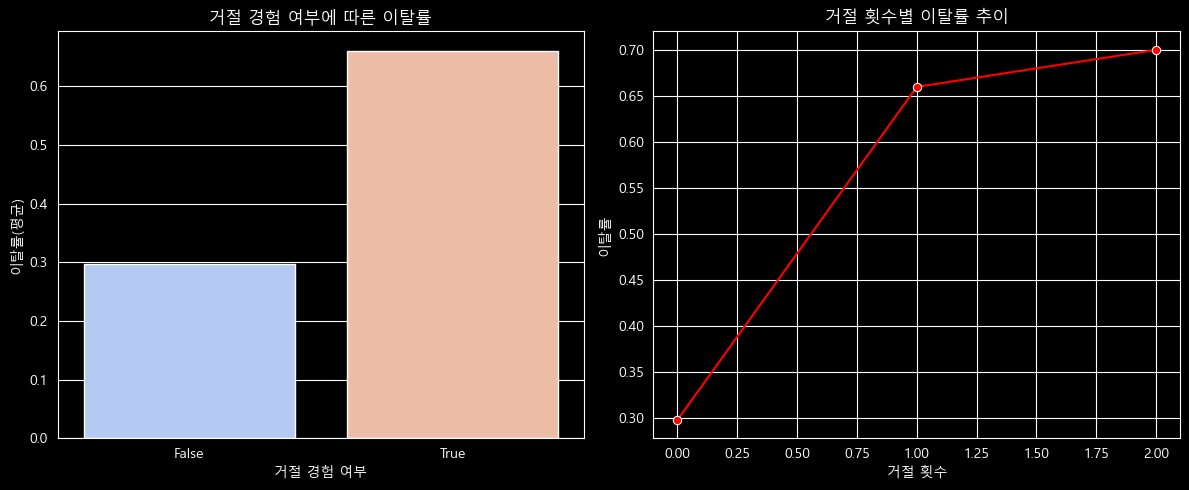

In [26]:
# 2. 시각화 (막대 그래프)
plt.figure(figsize=(12, 5))

# 왼쪽: 거절 경험 여부별 이탈률 (막대 그래프)
plt.subplot(1, 2, 1)
sns.barplot(
    data=reject_stats,
    x='거절 경험 여부',
    y='이탈률(평균)',
    hue='거절 경험 여부',
    palette='coolwarm',
    legend=False
)
plt.title('거절 경험 여부에 따른 이탈률')

# 오른쪽: 거절 횟수 증가에 따른 이탈률 변화 (선 그래프)
plt.subplot(1, 2, 2)
sns.lineplot(data=count_stats, x='거절 횟수', y='이탈률', marker='o', color='red')
plt.title('거절 횟수별 이탈률 추이')

plt.tight_layout()
plt.show()

## 모델학습 _수정필요

### 1. 불필요한 컬럼 삭제

In [14]:
drop_cols = ['customer_id', 'as_of_date', 'churn_type', 'churn_probability_true']
df_clean = churn_df.drop(columns=drop_cols)

### 2. 변수 생성
- 거절율
- 미지급비율

In [15]:
df_clean['rejection_rate'] = df_clean['num_rejected_claims_12m'] / (df_clean['num_claims_12m'] + 0.1)
df_clean['unpaid_ratio'] = 1 - df_clean['payout_ratio_12m']

### 3. Label encoding

In [28]:
str_cols = df_clean.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in str_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

### 4. 데이터 분리

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['churn_flag'])
y = df_clean['churn_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"변수 개수: {X_train.shape[1]}개")

### 5. 모델 예측 및 학습

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
clf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight={0:1, 1:5})
clf_model.fit(X_train, y_train)

y_pred = clf_model.predict(X_test)

print("=== 모델 예측 성능 ===")
print(f"전체 정확도 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score (이탈자 예측 최적화 지표): {f1_score(y_test, y_pred):.4f}")
print("\n[상세 리포트]")
print(classification_report(y_test, y_pred))

# 가설 검증: 어떤 변수가 이탈에 가장 큰 영향을 줬나?
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': clf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 설정한 가설이 맞는지 확인해보기
print("\n=== 변수 중요도 Top 10 ===")
print(importances.head(10))